# Lane Detection Test Notebook

This notebook runs quick sanity checks for the lane detection/demo code in this repository. It demonstrates classic OpenCV lane detection and an optional YOLOv8 + BEV pathway.

In [17]:
# Import project modules and helper functions
import sys

sys.path.append("../src")  # add repo src to path

from ui import road_lanes
from lane_demo import (
    try_load_yolo_model,
    get_birdseye_transform,
    warp_points,
    fit_lane_polynomial,
    compute_curvature_and_offset,
    PolynomialSmoother,
    median_point_filter,
)

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Loaded modules: road_lanes and lane_demo helpers")

Loaded modules: road_lanes and lane_demo helpers


In [ ]:
# List example files and sample assets
import os


sample_images = os.listdir("../assets/lane") if os.path.isdir("../assets/lane") else []
print("image:", sample_images)


image: ['test5.jpg', 'test6.jpg', 'test4.jpg', 'test2.jpg', 'test3.jpg', 'test1.jpg']


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

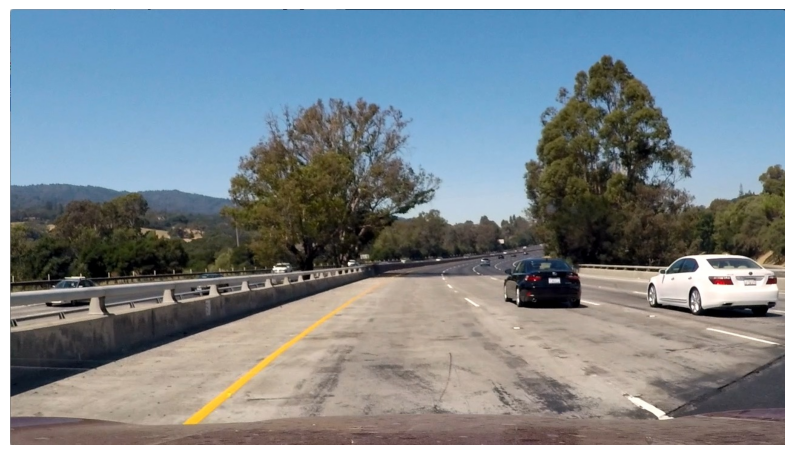

In [18]:
# Load a single frame and display
# Use the existing plt import (do not re-import). Iterate over filenames in sample_images,
# and skip files that cannot be read.
frame = cv2.imread(os.path.join("../assets/lane", "test1.jpg"))

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis("off")

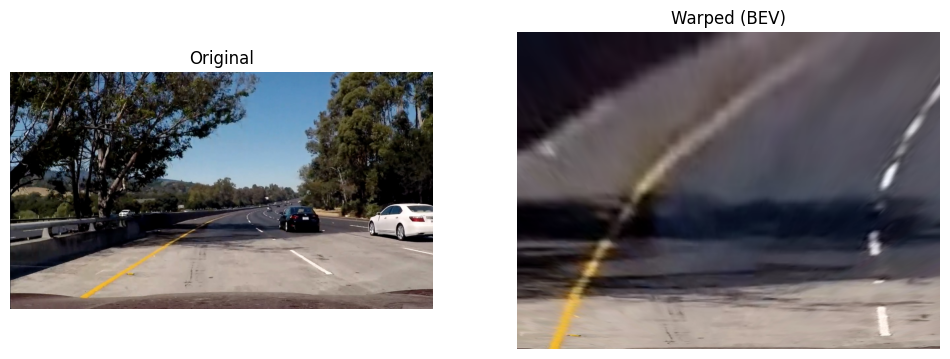

In [10]:
# Bird's-eye transform visualization
if frame is not None:
    M, Minv, size = get_birdseye_transform(frame)
    warped = cv2.warpPerspective(frame, M, size)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Original")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Warped (BEV)")
else:
    print("No frame to compute BEV")


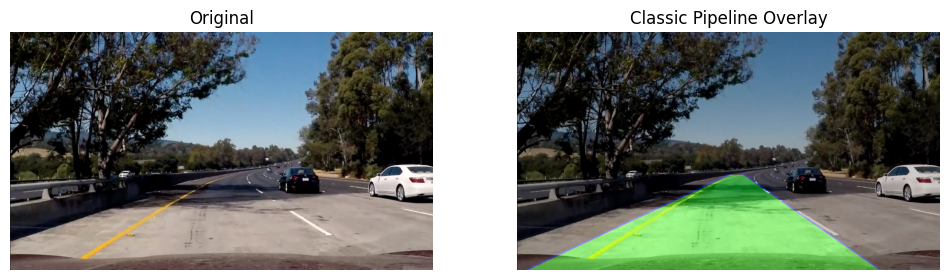

In [11]:
# Run the classic OpenCV pipeline and show overlay
if frame is not None:
    classic_out = road_lanes.lane_finding_pipeline(frame)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(classic_out, cv2.COLOR_BGR2RGB))
    plt.title("Classic Pipeline Overlay")
    plt.axis("off")
else:
    print("No frame to run classic pipeline")


## YOLO 

In [ ]:
from ultralytics import YOLO

# Load a model

model = YOLO("yolo11s-seg.pt")  # load a pretrained model (recommended for training)

YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
YOLO predictor loaded

0: 224x384 2 cars, 38.1ms
Speed: 6.5ms preprocess, 38.1ms inference, 1.2ms postprocess per image at shape (1, 3, 224, 384)
Detections: [(1080, 400, 1278, 513, 0.9027640223503113, 2), (819, 408, 941, 490, 0.7042524814605713, 2)]
YOLO timings: {'preprocess': 3.969998942920938e-07, 'inference': 0.05632698800036451, 'postprocess': 0.00016192099974432494}


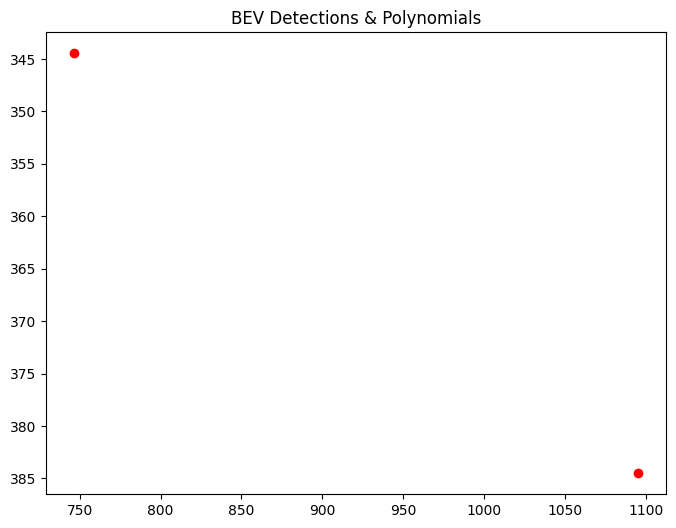

In [13]:
# Optional: Run YOLOv8 BEV pipeline if available
try:
    predict_yolo = try_load_yolo_model(weights_path="yolov8n.pt", imgsz=384)
    print("YOLO predictor loaded")
except Exception as e:
    predict_yolo = None
    print("YOLO unavailable:", e)

if frame is not None and predict_yolo is not None:
    dets = predict_yolo(frame)
    print("Detections:", dets)
    if hasattr(predict_yolo, "last_timings"):
        print("YOLO timings:", predict_yolo.last_timings)
    pts = []
    for x1, y1, x2, y2, conf, cls in dets:
        pts.append(((x1 + x2) / 2.0, y2))
    if pts:
        pts = np.array(pts, dtype=float)
        M, Minv, size = get_birdseye_transform(frame)
        bev_pts = warp_points(pts, M)
        left_poly, right_poly, left_pts, right_pts = fit_lane_polynomial(bev_pts)
        # show BEV points and poly
        plt.figure(figsize=(8, 6))
        plt.scatter(bev_pts[:, 0], bev_pts[:, 1], c="r")
        ys = np.linspace(0, size[1], 60)
        if left_poly is not None:
            plt.plot(left_poly(ys), ys, "g")
        if right_poly is not None:
            plt.plot(right_poly(ys), ys, "g")
        plt.gca().invert_yaxis()
        plt.title("BEV Detections & Polynomials")
    else:
        print("No detections to show.")
else:
    print("Skipping YOLO step (no predictor or frame)")

In [14]:
# Compute curvature and offset if polynomials exist
if "left_poly" in globals() or "right_poly" in globals():
    leftp = left_poly if "left_poly" in globals() else None
    rightp = right_poly if "right_poly" in globals() else None
    try:
        curv, offset, lane_px = compute_curvature_and_offset(leftp, rightp, size)
        print("Curvature (m):", curv)
        print("Offset (m):", offset)
    except Exception as e:
        print("Curvature/offset computation failed:", e)
else:
    print("No polynomials to compute curvature/offset")


Curvature (m): None
Offset (m): None


In [15]:
# Basic pytest-like assertions
assert frame is not None, "No sample frame loaded"
assert frame.ndim == 3 and frame.shape[2] == 3
out = road_lanes.lane_finding_pipeline(frame)
assert out is not None and out.shape == frame.shape
print("Basic tests passed")


Basic tests passed


In [16]:
# Measure per-stage timings for a few frames
import time

if sample_video is None:
    print("Skipping profiling: no sample video available")
else:
    cap = cv2.VideoCapture(sample_video)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    timings = {
        "read": [],
        "preprocess": [],
        "inference": [],
        "postprocess": [],
        "total": [],
    }
    for i in range(30):
        t0 = time.perf_counter()
        ret, f = cap.read()
        if not ret:
            break
        t_read = time.perf_counter() - t0
        t_pp0 = time.perf_counter()
        # minimal preprocessing
        img = cv2.resize(f, (640, int(f.shape[0] * 640 / f.shape[1])))
        t_pre = time.perf_counter() - t_pp0
        t_in0 = time.perf_counter()
        out_img = road_lanes.lane_finding_pipeline(img)
        t_infer = time.perf_counter() - t_in0
        t_post0 = time.perf_counter()
        # do a small postprocess (compose)
        _ = cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB)
        t_post = time.perf_counter() - t_post0
        timings["read"].append(t_read)
        timings["preprocess"].append(t_pre)
        timings["inference"].append(t_infer)
        timings["postprocess"].append(t_post)
        timings["total"].append(time.perf_counter() - t0)
    cap.release()
    import statistics

    print("Read median: %.3f ms" % (statistics.median(timings["read"]) * 1000))
    print(
        "Preprocess median: %.3f ms" % (statistics.median(timings["preprocess"]) * 1000)
    )
    print("Infer median: %.3f ms" % (statistics.median(timings["inference"]) * 1000))
    print("Post median: %.3f ms" % (statistics.median(timings["postprocess"]) * 1000))
    print("Total median: %.3f ms" % (statistics.median(timings["total"]) * 1000))


Skipping profiling: no sample video available


# Notes

- Use `--yolo-imgsz` and `--yolo-weights` for YOLO experiments in `lane_demo.py`.
- For Jetson/embedded, convert YOLO model to ONNX and TensorRT; for Intel NCS, convert with OpenVINO.
- Tune `PolynomialSmoother(alpha=...)` in the code to reduce jitter/lag tradeoff.

# To run the full pipeline outside the notebook:
# python src/lane_demo.py --source src/ui/assets/input.mp4 --use-yolo --display
